# What is this notebook about?

This notebook aims to illustrates the difference between statistics and probabilites. We use some aggregation from [real estate data across the United Kingdom](https://www.kaggle.com/datasets/patriciaryserwelch/united-kingdom-real-estate-and-population-data). The finding are purely illustrative - the origin of the data has yet to be verified.

# Upload data 


In [3]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import os




## Let's prepare the data

In [4]:
file = '/kaggle/input/united-kingdom-real-estate-and-population-data/data_month.csv'
data = pd.read_csv(file)
data.shape

(24, 7)

In [5]:
data.columns

Index(['Unnamed: 0', 'index', 'Month', 'Year', 'Old/New', 'Price', 'count'], dtype='object')

In [40]:
data =data.loc[:,['Month','Year','Old/New','count','Price']]
data

,Month,Year,Old/New,count,Price
0,1,2008,N,27356,6156391634
1,1,2008,Y,2348,461524828
2,6,2008,N,24612,5452367446
3,6,2008,Y,5265,1126113525
4,7,2008,N,23640,5466597264
5,7,2008,Y,3020,621581595
6,8,2008,N,21379,4786991918
7,8,2008,Y,2805,589737160
8,9,2008,N,18077,4008705471
9,9,2008,Y,2986,591857312


In [23]:
data_grouped = data.groupby(['Month','Old/New']).sum().reset_index()
data_grouped

,Month,Old/New,Unnamed: 0,index,Year,Price,count
0,1,N,0,0,2008,6156391634,27356
1,1,Y,1,1,2008,461524828,2348
2,2,N,2,2,2008,6233863621,28965
3,2,Y,3,3,2008,566588036,2617
4,3,N,4,4,2008,5602310338,25861
5,3,Y,5,5,2008,808916521,3911
6,4,N,6,6,2008,6120494600,27968
7,4,Y,7,7,2008,779511788,3892
8,5,N,8,8,2008,6397384856,29121
9,5,Y,9,9,2008,778989366,3657


We conduct a horizontal splitting based on whether a property is old or new. We group the data by month and counted the number of property that has changed name of proprietor. For that reason, we refer the this count as _name_.

In [35]:
filter_rows = data_grouped['Old/New'] == 'N'
filter_cols = ['Month','Old/New', 'Price','count']
old = data_grouped.loc[filter_rows,filter_cols]
old = old.groupby(['Month','Old/New']).sum().reset_index()
old['PricePerProperty'] = old['Price']/old['count']
old

,Month,Old/New,Price,count,PricePerProperty
0,1,N,6156391634,27356,225047.215748
1,2,N,6233863621,28965,215220.563473
2,3,N,5602310338,25861,216631.620510
3,4,N,6120494600,27968,218839.194794
4,5,N,6397384856,29121,219682.869956
5,6,N,5452367446,24612,221532.888266
6,7,N,5466597264,23640,231243.539086
7,8,N,4786991918,21379,223910.936807
8,9,N,4008705471,18077,221757.231344
9,10,N,4158229278,19618,211959.897951


In [41]:
filter_rows = data_grouped['Old/New'] == 'Y'
filter_cols = ['Month','Old/New', 'Price','count']
new = data_grouped.loc[filter_rows,filter_cols]
new = new.groupby(['Month','Old/New']).sum().reset_index()
new['PricePerProperty'] = new['Price']/new['count']
new

,Month,Old/New,Price,count,PricePerProperty
0,1,Y,461524828,2348,196560.829642
1,2,Y,566588036,2617,216502.879633
2,3,Y,808916521,3911,206831.122731
3,4,Y,779511788,3892,200285.659815
4,5,Y,778989366,3657,213013.225595
5,6,Y,1126113525,5265,213886.709402
6,7,Y,621581595,3020,205821.720199
7,8,Y,589737160,2805,210244.976827
8,9,Y,591857312,2986,198210.754186
9,10,Y,570573385,2969,192176.956888


# Introduction to statistics

[Statistics](https://en.wikipedia.org/wiki/Wikipedia:Statistics) is a branch of mathematics that pertains to the collection, analysis, interpretation or explanation, and presentation of data, or as a branch of mathematics. 

We analyse the number of properties in the UK in which they have changed owners. 

We discover both distribution differ from each - the number newly-built properties appear to be a lot less that older properties. In both distribution the range of values appears to be quite large, suggesting some value may impose some skewness to the normal distrinution.

,Month,Price,count,PricePerProperty
count,12.000000,1.200000e+01,12.000000,12.000000
mean,6.500000,5.057121e+09,23140.083333,217612.353024
std,3.605551,1.182803e+09,5020.953286,8535.367300
min,1.000000,3.122499e+09,15315.000000,201637.255692
25%,3.750000,4.120848e+09,19232.750000,214405.397093
50%,6.500000,5.459482e+09,24126.000000,219261.032375
75%,9.250000,6.129469e+09,27509.000000,222295.657710
max,12.000000,6.397385e+09,29121.000000,231243.539086


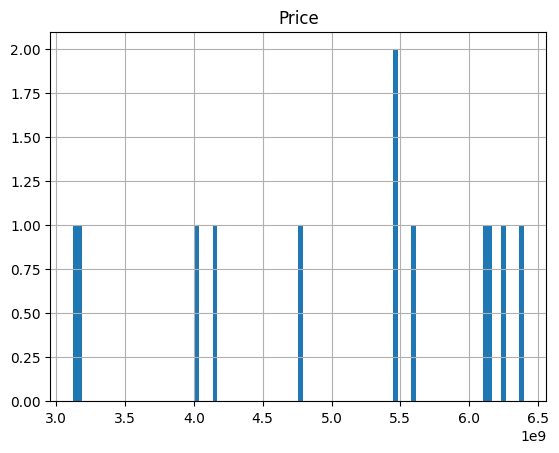

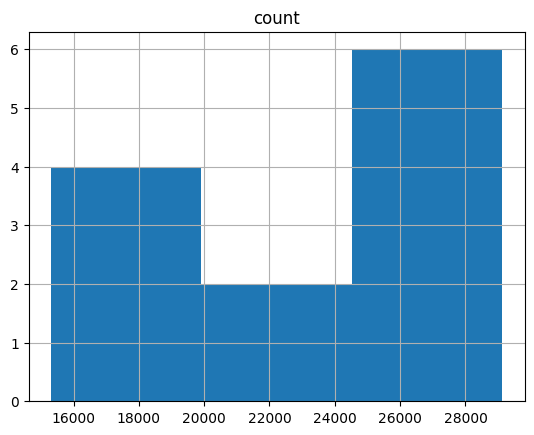

In [54]:
old.hist('Price', bins = 100)
old.hist('count', bins = 3)
old.describe()



,Month,Price,count,PricePerProperty
count,12.000000,1.200000e+01,12.000000,12.000000
mean,6.500000,6.798013e+08,3370.583333,201468.498679
std,3.605551,1.795806e+08,830.814218,11984.763576
min,1.000000,4.615248e+08,2348.000000,176358.740139
25%,3.750000,5.695770e+08,2802.250000,195464.861454
50%,6.500000,6.067195e+08,3003.000000,203053.690007
75%,9.250000,7.791200e+08,3896.750000,210937.039019
max,12.000000,1.126114e+09,5265.000000,216502.879633


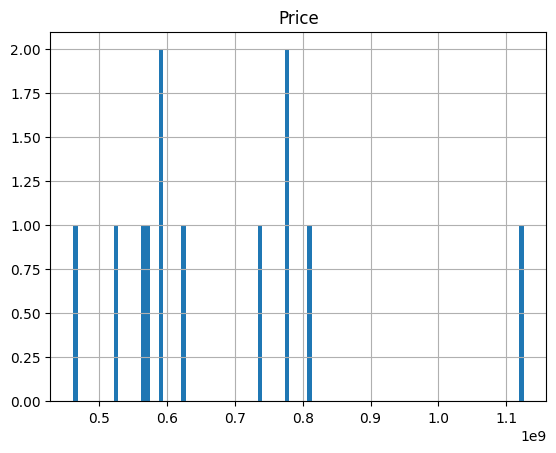

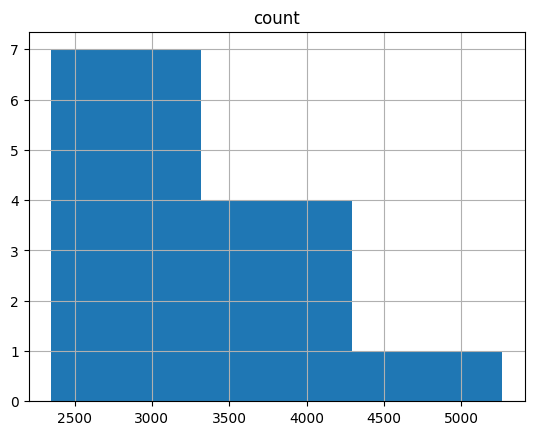

In [55]:
new.hist('Price', bins = 100)
new.hist('count', bins = 3)
new.describe()

# Introduction to probabilities

[Probability](https://en.wikipedia.org/wiki/Probability) is a branch of math that used to describe the likelihood an event may occur. [A more detailed description](https://www.ncl.ac.uk/webtemplate/ask-assets/external/maths-resources/introduction-to-probability.html) introduces those concepts. 

An estate agency may wish to discover the month to likelihood of receiving the biggest commissions.


# Let's transform the data into ratios

In [60]:
total_price = old['Price'].sum()
total_count = old['count'].sum()
print('Total price ', total_price)
print('Total count ' , total_count)
old['month_ratio'] = old['Price']/total_price
old['count_ratio'] = old['count']/total_count
old


Total price  60685453433
Total count  277681


,Month,Old/New,Price,count,PricePerProperty,month_ratio,count_ratio
0,1,N,6156391634,27356,225047.215748,0.101448,0.098516
1,2,N,6233863621,28965,215220.563473,0.102724,0.104310
2,3,N,5602310338,25861,216631.620510,0.092317,0.093132
3,4,N,6120494600,27968,218839.194794,0.100856,0.100720
4,5,N,6397384856,29121,219682.869956,0.105419,0.104872
5,6,N,5452367446,24612,221532.888266,0.089846,0.088634
6,7,N,5466597264,23640,231243.539086,0.090081,0.085134
7,8,N,4786991918,21379,223910.936807,0.078882,0.076991
8,9,N,4008705471,18077,221757.231344,0.066057,0.065100
9,10,N,4158229278,19618,211959.897951,0.068521,0.070649


In [61]:
total_price = new['Price'].sum()
total_count = new['count'].sum()
print('Total price ', total_price)
print('Total count ' , total_count)
new['month_ratio'] = new['Price']/total_price
new['count_ratio'] = new['count']/total_count
new


Total price  8157615301
Total count  40447


,Month,Old/New,Price,count,PricePerProperty,month_ratio,count_ratio
0,1,Y,461524828,2348,196560.829642,0.056576,0.058051
1,2,Y,566588036,2617,216502.879633,0.069455,0.064702
2,3,Y,808916521,3911,206831.122731,0.099161,0.096694
3,4,Y,779511788,3892,200285.659815,0.095556,0.096225
4,5,Y,778989366,3657,213013.225595,0.095492,0.090415
5,6,Y,1126113525,5265,213886.709402,0.138044,0.130170
6,7,Y,621581595,3020,205821.720199,0.076196,0.074666
7,8,Y,589737160,2805,210244.976827,0.072293,0.069350
8,9,Y,591857312,2986,198210.754186,0.072553,0.073825
9,10,Y,570573385,2969,192176.956888,0.069944,0.073405


In [68]:
all_data = pd.concat([old, new],ignore_index = True)
all_data


,Month,Old/New,Price,count,PricePerProperty,month_ratio,count_ratio
0,1,N,6156391634,27356,225047.215748,0.101448,0.098516
1,2,N,6233863621,28965,215220.563473,0.102724,0.104310
2,3,N,5602310338,25861,216631.620510,0.092317,0.093132
3,4,N,6120494600,27968,218839.194794,0.100856,0.100720
4,5,N,6397384856,29121,219682.869956,0.105419,0.104872
5,6,N,5452367446,24612,221532.888266,0.089846,0.088634
6,7,N,5466597264,23640,231243.539086,0.090081,0.085134
7,8,N,4786991918,21379,223910.936807,0.078882,0.076991
8,9,N,4008705471,18077,221757.231344,0.066057,0.065100
9,10,N,4158229278,19618,211959.897951,0.068521,0.070649


## What is the probability to get bonus if an estate agent sells new houses?


$P(new houses)$


In [81]:
total_exchange   = all_data['count'].sum() 
total_new_houses =  new['count'].sum()
prob_new         = new['count'].sum()/all_data['count'].sum()

print('Total of no property exchanged             : ', total_exchange)
print('Total of new property exchanged            : ', total_new_houses)
print('P(get a bonus if a I sell some new houses) : ', prob_new )


Total of no property exchanged             :  318128
Total of new property exchanged            :  40447
P(get a bonus if a I sell some new houses) :  0.127140647789569


## What is the probability to get bonus if an estate agent sells old houses?


$P(old houses)$


In [83]:
total_old_houses = old['count'].sum()
prob_old        = old['count'].sum()/all_data['count'].sum()

print('Total of no property exchanged             : ', total_exchange)
print('Total of old property exchanged            : ', total_old_houses)
print('P(get a bonus if  I sell some new houses) : ', prob_old )


Total of no property exchanged             :  318128
Total of old property exchanged            :  277681
P(get a bonus if a I sell some new houses) :  0.872859352210431


## What is the probability to get bonus if an estate agent sells old and new houses?


$P(old houses And new houses) = P(old houses) * P(new houses)$


In [84]:
print('P(get a bonus if I sell some new houses and old houses) : ' , prob_old * prob_new)

P(get a bonus if I sell some new houses and old houses) :  0.11097590346921775


In [83]:
total_old_houses = old['count'].sum()
prob_old        = old['count'].sum()/all_data['count'].sum()

print('Total of no property exchanged             : ', total_exchange)
print('Total of old property exchanged            : ', total_old_houses)
print('P(get a bonus if  I sell some new houses) : ', prob_old )


Total of no property exchanged             :  318128
Total of old property exchanged            :  277681
P(get a bonus if a I sell some new houses) :  0.872859352210431


## What is the probability to get bonus if an estate agent sells old or new houses?


$P(old houses OR new houses) = P(old houses) + P(new houses)$


In [85]:
print('P(get a bonus if I sell some new houses and old houses) : ' , prob_old + prob_new)

P(get a bonus if I sell some new houses and old houses) :  1.0


In [83]:
total_old_houses = old['count'].sum()
prob_old        = old['count'].sum()/all_data['count'].sum()

print('Total of no property exchanged             : ', total_exchange)
print('Total of old property exchanged            : ', total_old_houses)
print('P(get a bonus if  I sell some new houses) : ', prob_old )


Total of no property exchanged             :  318128
Total of old property exchanged            :  277681
P(get a bonus if a I sell some new houses) :  0.872859352210431


## What is the probability that an estate agent  can get a bonus in January?

The event is to receive a bonus in January from any types of properties.


$P(bonus | january)$

In [72]:
filter = all_data.Month == 1
all_data.loc[filter, ['month_ratio']].sum()

month_ratio    0.158024
dtype: float64